#### I : Učitavanje biblioteka i definisanje putanja

<small>

Kao i u prethodnom notebooku, učitavaju se putanje i nazivi slika iz trening i validacionog skupa, koji će se koristiti u procesu pripreme podataka.

</small>

In [24]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

train_path = "../data/DIV2K_train_HR"
val_path = "../data/DIV2K_valid_HR"

train_images = os.listdir(train_path)
val_images = os.listdir(val_path)

#### II: Testiranje postupka izdvajanja LR–HR patch-eva i downsampling-a

<small>

U ovom koraku proveravamo da li postupak izdvajanja patch-eva funkcioniše ispravno pre nego što ga primenimo na ceo skup podataka.

Prethodno je potrebno definisati **faktor skaliranja** koji ćemo koristiti u **procesu super-rezolucije**.

- Odabrali smo **×4 super-rezoluciju** jer predstavlja **standardan** i **dovoljno izazovan scenario** za **super-rezoluciju**, pri čemu model treba da rekonstruiše sliku čija su širina i visina **četiri puta veće** od **ulazne LR slike**. 
- Ovaj faktor omogućava da se jasno ispita **sposobnost modela** da iz **slike niže rezolucije** obnovi **izgubljene detalje** i dobije **kvalitetniju HR sliku**.

</small>

##### 2.1) Definisanje parametara i formiranje HR patch-a

<small>

Kako originalne slike imaju **različite dimenzije**, za potrebe treniranja biće izdvojeni **delovi slika** **jednakih dimenzija**.

- U ovom projektu koristiće se **HR patch** dimenzija $128×128$ piksela, dok će odgovarajuća **LR verzija** biti dimenzija $32×32$ piksela, što odgovara faktoru **super-rezolucije ×4**.
- **Patch**-evi su **mali delovi** **isečeni** iz **velikih slika** koje **CNN** koristi umesto da obrađuje **celu sliku** odjednom.
- Time **smanjujemo** potrebnu **memoriju**, dobijamo **mnogo više trening primera** iz jedne slike i omogućavamo mreži da **bolje uči lokalne detalje** poput **ivica**, **tekstura** i **finih struktura**.

</small>

In [25]:
# Definisanje parametara

SCALE = 4
HR_SIZE = 128
LR_SIZE = HR_SIZE // SCALE

# HR patch

def random_crop(image, size):
    width, height = image.size

    if width < size or height < size:
        raise ValueError("Slika je manja od zadate dimenzije.")

    left = random.randint(0, width - size)
    top = random.randint(0, height - size)

    crop = image.crop((left, top, left + size, top + size))

    return crop

img = Image.open(os.path.join(train_path, train_images[0])).convert("RGB")

hr_patch = random_crop(img, HR_SIZE)

print("Originalna slika:", img.size)
print("HR patch:", hr_patch.size)

Originalna slika: (2040, 1404)
HR patch: (128, 128)


<small>

> Iz svake visokorezolucione slike **nasumično** se **izdvaja patch** dimenzija $128×128$ piksela.<br>
> Na ovaj način se **velike slike** pretvaraju u **manje uzorke** pogodne za **efikasnije** treniranje neuronske mreže.<br>

> Dimenziju $128×128$ smo **odabrali** kao deo pripreme podataka, jer predstavlja dobar kompromis između **očuvanja dovoljno detalja** za učenje modela, **razumnih memorijskih zahteva** i mogućnosti da se iz velikih **DIV2K** slika dobije **veliki broj trening primera**.<br>

> Po potrebi možemo eksperimentisati i sa **drugim dimenzijama patch**-eva, kao što su $64×64$ ili $256×256$. 

</small>

##### 2.2) Downsampling – formiranje LR slike

<small>

Sada od **HR patch**-a pravimo njegovu **LR verziju**.

- Pošto smo odabrali **×4 super-rezoluciju**, **LR slika** treba da bude **četiri puta manja** po **širini** i **visini** u odnosu na **HR sliku**. 
- Zbog toga se **HR patch** dimenzije $128×128$ smanjuje na $32×32$ piksela: $128 / 4 = 32$
- Na taj način dobijamo $16$ **puta manje piksela**, jer se **obe dimenzije smanjuju četiri puta**. 
- Smanjivanje se vrši pomoću **BICUBIC interpolacije**, čime dobijamo odgovarajući **LR–HR par** koji će se koristiti za treniranje modela super-rezolucije.

</small>

HR patch: (128, 128)
LR patch: (32, 32)


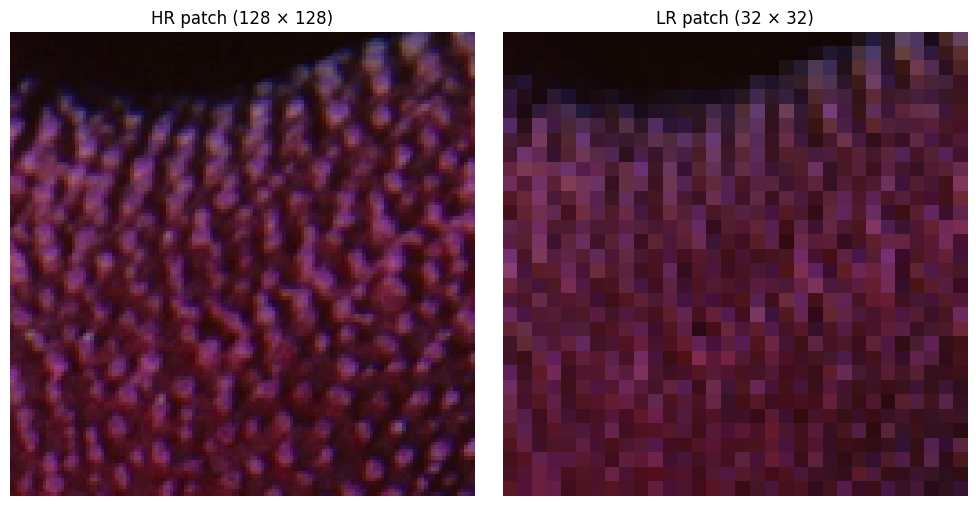

In [26]:
lr_patch = hr_patch.resize((LR_SIZE, LR_SIZE),Image.Resampling.BICUBIC)

print("HR patch:", hr_patch.size)
print("LR patch:", lr_patch.size)

# Prikaz HR i LR patch-a
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(hr_patch)
axes[0].set_title("HR patch (128 × 128)")
axes[0].axis("off")

axes[1].imshow(lr_patch)
axes[1].set_title("LR patch (32 × 32)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<small>

> **HR** i **LR patch** prikazujemo jedan pored drugog kako bismo lakše uočili **razliku** u **rezoluciji** i **kvalitetu slike**.

</small>

#### III : Formiranje trening i validacionog skupa pomoću LR–HR patch-eva i downsampling-a

<small>

Postupak koji smo prethodno demonstrirali na pojedinačnoj slici sada primenjujemo na **ceo skup podataka**.

- Iz **svake slike** **nasumično izdvajamo** $10$ **patch**-eva dimenzije $128×128$.
- Patch-evi se **biraju nezavisno**, pa se mogu **delimično preklapati**, što omogućava **korišćenje različitih delova slike** i **povećava** broj trening primera.


Za svaki izdvojeni **HR patch** formira se odgovarajući **LR patch**, čime dobijamo **LR–HR parove** koji predstavljaju **ulazne** i **ciljne podatke** modela.

- **LR slike** predstavljaju **ulazne podatke** modela, odnosno **slike niže rezolucije** koje model dobija kao **input**. 
- **HR slike** predstavljaju **ciljne podatke**, odnosno **slike visoke rezolucije** koje **model** treba da **rekonstruiše** na osnovu **datog LR ulaza**.


</small>

In [27]:
def create_dataset(image_names, image_path):
    lr_images = []
    hr_images = []

    for fname in image_names:

        img = Image.open(
            os.path.join(image_path, fname)
        ).convert("RGB")

        for _ in range(10):

            # HR patch
            hr = random_crop(img, HR_SIZE)

            # LR patch
            lr = hr.resize((LR_SIZE, LR_SIZE),Image.Resampling.BICUBIC)

            hr_images.append(np.array(hr))
            lr_images.append(np.array(lr))

    return np.array(lr_images), np.array(hr_images)

X_train, y_train = create_dataset(train_images,train_path)
X_val, y_val = create_dataset(val_images,val_path)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (8000, 32, 32, 3)
y_train: (8000, 128, 128, 3)
X_val: (1000, 32, 32, 3)
y_val: (1000, 128, 128, 3)


<small>

> Na isti način, **HR patch**-eve smanjujemo (**downsampling**) na odgovarajuću **LR rezoluciju** koristeći **BICUBIC interpolaciju**, čime dobijamo odgovarajuće **LR patch**-eve i formiramo **LR–HR parove** za trening i validaciju modela.<br>
> Nakon formiranja skupa podataka, **trening skup** sadrži $8000$ **LR–HR parova**, dok **validacioni skup** sadrži $1000$ **LR–HR parova**. <br>

> **LR patch**-evi predstavljaju **ulazne podatke** dimenzija $32×32×3$, dok su **HR patch**-evi **ciljne vrednosti** dimenzija $128×128×3$, pri čemu $3$ **kanala** odgovaraju **RGB formatu**.<br>

</small>

#### IV : Vizuelna provera pripremljenog trening skupa

<small>

Nakon pripreme podataka, vršimo **vizuelnu proveru** nekoliko nasumičnih **formiranih LR–HR parova** kako bismo proverili da su **slike odgovarajućih dimenzija**, da je **downsampling** pravilno izvršen i da između LR i HR slika postoji **očekivana razlika u rezoluciji**.

</small>

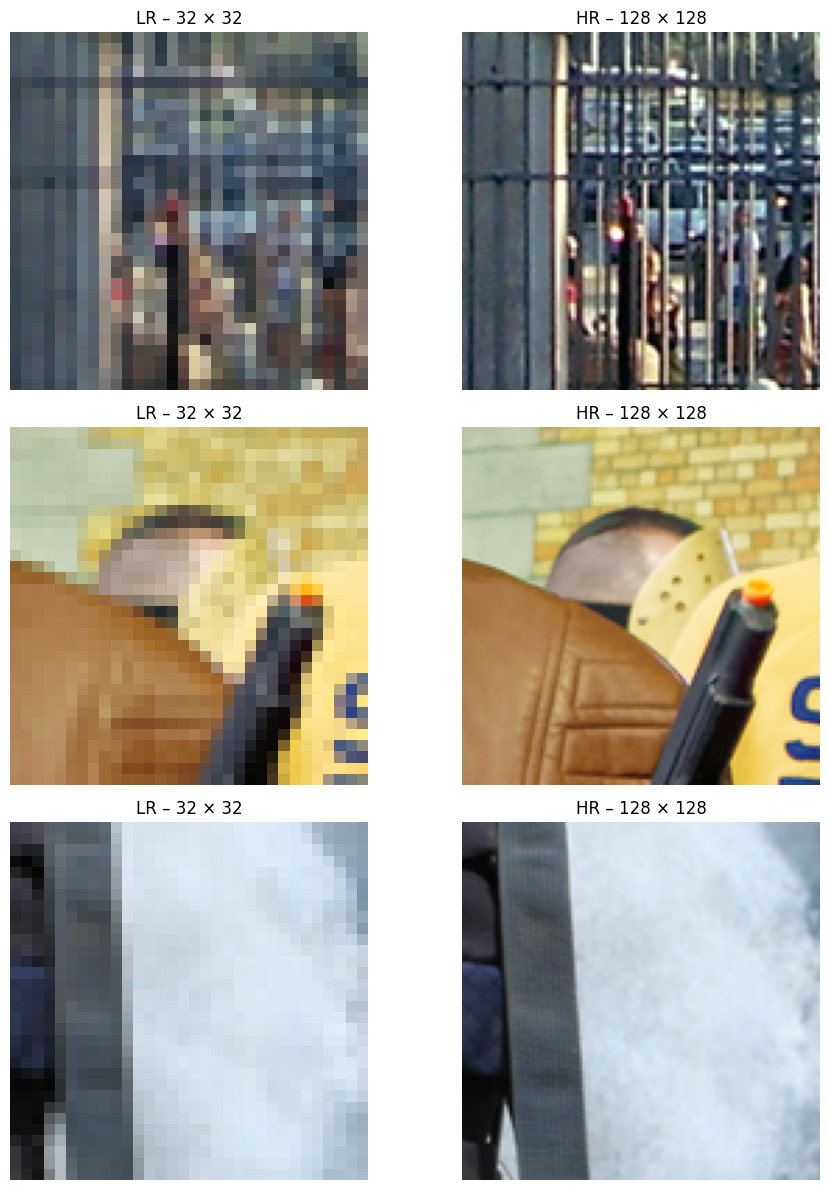

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

random_indices = random.sample(range(len(X_train)), 3)

for i, idx in enumerate(random_indices):

    axes[i, 0].imshow(X_train[idx])
    axes[i, 0].set_title("LR – 32 × 32")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_train[idx])
    axes[i, 1].set_title("HR – 128 × 128")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

<small>

> Kao što se može videti, **LR** i **HR patch**-evi **odgovaraju jedan drugom**, a **razlika u rezoluciji** je jasno **uočljiva**, što potvrđuje da je **postupak pripreme trening i validacionih podataka** uspešno izvršen.
</small>

#### V : Priprema test skupova

<small>

Za **testiranje modela** biće korišćeni su **Set5** i **Set14** skupovi podataka. 

- S obzirom na to da je model namenjen **super-rezoluciji** sa ***faktorom uvećanja ×4**, iz oba skupa biće korišćeni podaci iz $image_SRF_4$ foldera.
- Za svaki skup izdvojene su odgovarajuće **LR** i **HR** slike. 
- Slike iz **oba test skupa** biće **učitane**, **normalizovane** na opseg $[0, 1]$ i **sačuvane** u odgovarajućem formatu, kako bi se kasnije mogle direktno koristiti za **evaluaciju modela**.

</small>

In [32]:
set5_hr_path = "../data/Set5/image_SRF_4/HR"
set5_lr_path = "../data/Set5/image_SRF_4/LR"

set14_hr_path = "../data/Set14/image_SRF_4/HR"
set14_lr_path = "../data/Set14/image_SRF_4/LR"

X_test_set5, y_test_set5 = [], []
X_test_set14, y_test_set14 = [], []

all_rgb = True

for fname in sorted(os.listdir(set5_hr_path)):

    hr = Image.open(os.path.join(set5_hr_path, fname)).convert("RGB")
    lr = Image.open(os.path.join(set5_lr_path, fname)).convert("RGB")

    all_rgb &= hr.mode == "RGB" and lr.mode == "RGB"

    X_test_set5.append(np.array(lr, dtype=np.float32) / 255.0)
    y_test_set5.append(np.array(hr, dtype=np.float32) / 255.0)

for fname in sorted(os.listdir(set14_hr_path)):
    
    hr = Image.open(os.path.join(set14_hr_path, fname)).convert("RGB")
    lr = Image.open(os.path.join(set14_lr_path, fname)).convert("RGB")

    all_rgb &= hr.mode == "RGB" and lr.mode == "RGB"

    X_test_set14.append(np.array(lr, dtype=np.float32) / 255.0)
    y_test_set14.append(np.array(hr, dtype=np.float32) / 255.0)

print("Sve slike su RGB:", all_rgb)

print("\nSET5 - Normalizovan")
print("X_test:", len(X_test_set5), "slika | opseg:", min(x.min() for x in X_test_set5), "-", max(x.max() for x in X_test_set5))
print("y_test:", len(y_test_set5), "slika | opseg:", min(y.min() for y in y_test_set5), "-", max(y.max() for y in y_test_set5))

print("\nSET14 - Normalizovan")
print("X_test:", len(X_test_set14), "slika | opseg:", min(x.min() for x in X_test_set14), "-", max(x.max() for x in X_test_set14))
print("y_test:", len(y_test_set14), "slika | opseg:", min(y.min() for y in y_test_set14), "-", max(y.max() for y in y_test_set14))

print("\nOblik test skupova:")
print(f"\nX_test_set5: ({len(X_test_set5)}, H, W, {X_test_set5[0].shape[-1]})")
print(f"y_test_set5: ({len(y_test_set5)}, H, W, {y_test_set5[0].shape[-1]})")

print(f"X_test_set14: ({len(X_test_set14)}, H, W, {X_test_set14[0].shape[-1]})")
print(f"y_test_set14: ({len(y_test_set14)}, H, W, {y_test_set14[0].shape[-1]})")

Sve slike su RGB: True

SET5 - Normalizovan
X_test: 5 slika | opseg: 0.0 - 1.0
y_test: 5 slika | opseg: 0.0 - 1.0

SET14 - Normalizovan
X_test: 14 slika | opseg: 0.0 - 1.0
y_test: 14 slika | opseg: 0.0 - 1.0

Oblik test skupova:

X_test_set5: (5, H, W, 3)
y_test_set5: (5, H, W, 3)
X_test_set14: (14, H, W, 3)
y_test_set14: (14, H, W, 3)


<small>

> Sve slike u **Set5** i **Set14 test skupovima** prevedene su u **RGB format**, odnosno sadrže $3$ **kanala**, čime su **usklađene** sa **ulaznim formatom modela**. <br>
> **Set5** sadrži $5$, dok **Set14** sadrži $14$ **LR–HR parova** slika. <br>
> Za razliku od trening i validacionog skupa, **test slike** se koriste u **originalnim dimenzijama**, koje se **razlikuju** između slika, zbog čega su **visina** i **širina** označene sa $H$ , $W$. 

</small>

#### VI : Vizuelna provera pripremljenih test skupova

<small>

Nakon pripreme test skupova, vršimo vizuelnu proveru nekoliko **nasumičnih LR–HR parova** iz **Set5** i **Set14** skupova kako bismo proverili da su odgovarajuće LR i HR slike **pravilno uparene**, da je između njih **očuvan faktor skaliranja ×4** i da postoji očekivana **razlika u rezoluciji**.

</small>

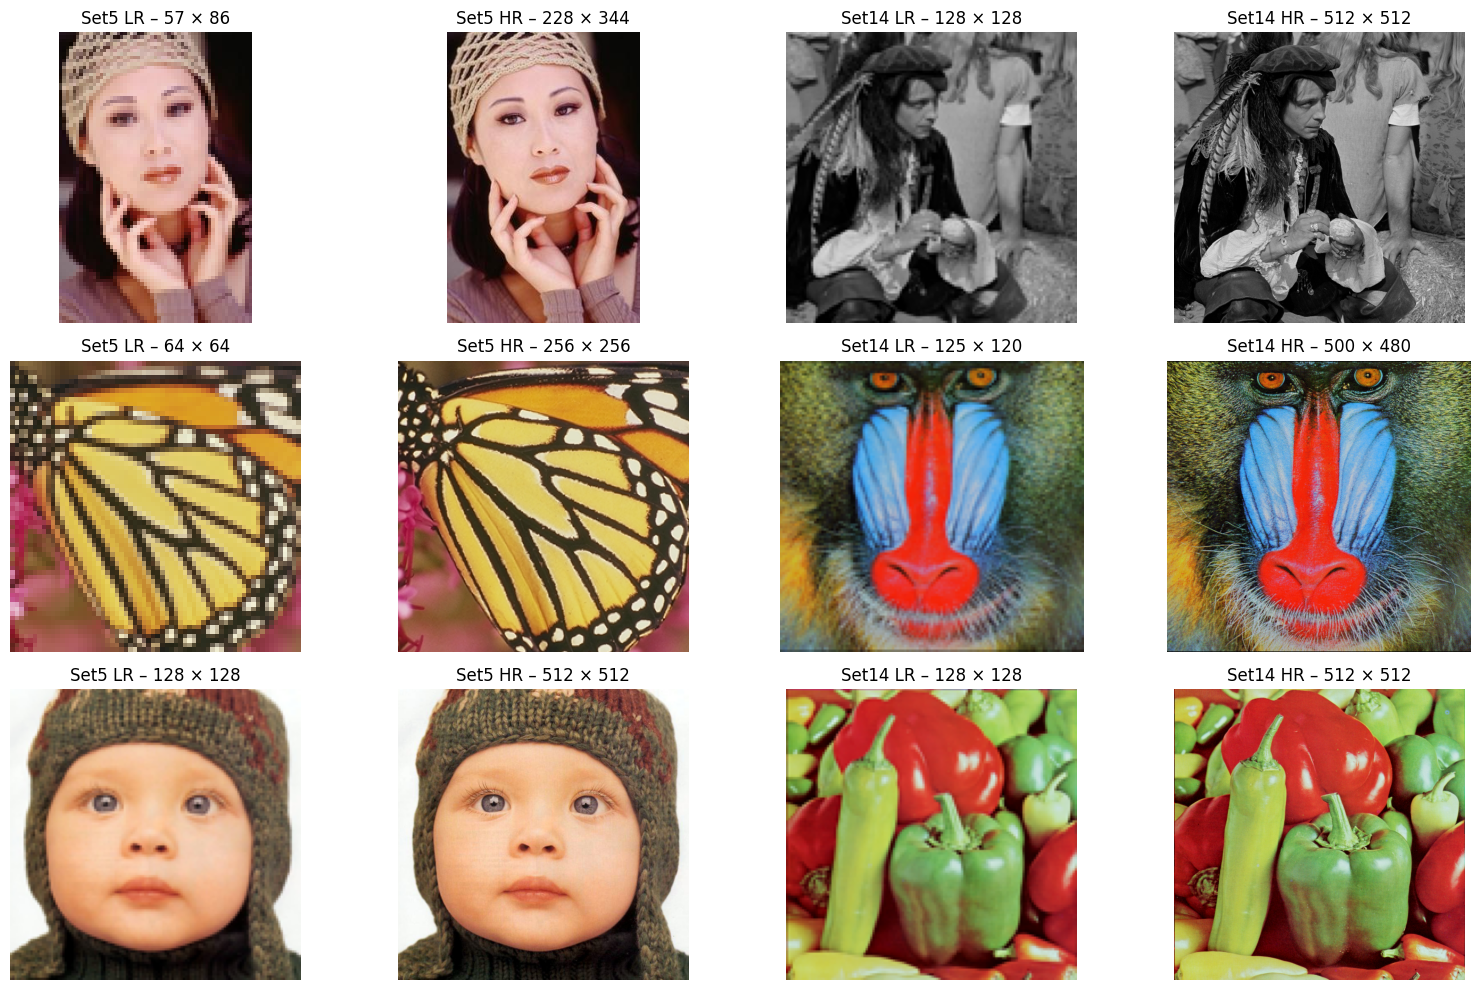

In [34]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

indices_set5 = random.sample(range(len(X_test_set5)), 3)
indices_set14 = random.sample(range(len(X_test_set14)), 3)

for i in range(3):

    idx5 = indices_set5[i]
    idx14 = indices_set14[i]

    axes[i, 0].imshow(X_test_set5[idx5])
    axes[i, 0].set_title(
        f"Set5 LR – {X_test_set5[idx5].shape[1]} × {X_test_set5[idx5].shape[0]}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_test_set5[idx5])
    axes[i, 1].set_title(
        f"Set5 HR – {y_test_set5[idx5].shape[1]} × {y_test_set5[idx5].shape[0]}"
    )
    axes[i, 1].axis("off")

    axes[i, 2].imshow(X_test_set14[idx14])
    axes[i, 2].set_title(
        f"Set14 LR – {X_test_set14[idx14].shape[1]} × {X_test_set14[idx14].shape[0]}"
    )
    axes[i, 2].axis("off")

    axes[i, 3].imshow(y_test_set14[idx14])
    axes[i, 3].set_title(
        f"Set14 HR – {y_test_set14[idx14].shape[1]} × {y_test_set14[idx14].shape[0]}"
    )
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

<small>

> Na prikazanim primerima iz **Set5** i **Set14** skupova vidi se da su LR i HR slike **pravilno uparene** i da predstavljaju **isti sadržaj**. <br>
> **Dimenzije prikazanih parova** potvrđuju da je između LR i HR slika **očuvan faktor skaliranja ×4**. <br>
> Kod **LR slika** primetan je **gubitak finih detalja** i **oštrine**, kao i **izraženija pikselizacija**, dok odgovarajuće **HR slike** sadrže **jasnije ivice**, **teksture** i **detalje**. 

</small>

#### VII : Čuvanje pripremljenih trening, validacionih i test skupova

<small>

Nakon završene pripreme podataka, **trening** i **validacioni skup** se čuvaju u  $.npy$ formatu, kako bi se pripremljeni **LR** i **HR podaci** mogli kasnije **jednostavno učitati** i koristiti za **treniranje modela**, bez ponavljanja postupka pripreme.

Nakon završene pripreme podataka, **test skupovi Set5** i **Set14** čuvaju se u $.npz$ formatu, kako bi se **pripremljeni** i **normalizovani LR** i **HR podaci** mogli kasnije **jednostavno učitati** i koristiti za **evaluaciju modela**, bez ponavljanja postupka pripreme. Za razliku od trening i validacionog skupa, $.npz$ format se koristi zbog **različitih dimenzija slika** unutar test skupova.

</small>

In [35]:
np.save("../data/X_train.npy", X_train)
np.save("../data/y_train.npy", y_train)
np.save("../data/X_val.npy", X_val)
np.save("../data/y_val.npy", y_val)

np.savez("../data/Set5_test.npz", **{f"X_{i}": X_test_set5[i] for i in range(len(X_test_set5))}, **{f"y_{i}": y_test_set5[i] for i in range(len(y_test_set5))})
np.savez("../data/Set14_test.npz", **{f"X_{i}": X_test_set14[i] for i in range(len(X_test_set14))}, **{f"y_{i}": y_test_set14[i] for i in range(len(y_test_set14))})

<small>

> Ovim je **proces pripreme podataka završen**. <br>
> Trening, validacioni i test skupovi su **pripremljeni** i **sačuvani** u **odgovarajućem formatu**, tako da se mogu **direktno koristiti** u narednim fazama treniranja i evaluacije modela.

</small>